In [1]:
import pandas as pd

# Load weather-enhanced solar predictions
solar_pred = pd.read_csv(
    "/content/solar_weather_predictions.csv"
)

# Load weather-enhanced load predictions
load_pred = pd.read_csv(
    "/content/load_weather_predictions.csv"
)

# Convert timestamps
solar_pred["Timestamp"] = pd.to_datetime(solar_pred["Timestamp"])
load_pred["Timestamp"] = pd.to_datetime(load_pred["Timestamp"])

print("Solar predictions:")
print(solar_pred.shape)
display(solar_pred.head())

print("\nLoad predictions:")
print(load_pred.shape)
display(load_pred.head())

Solar predictions:
(2578, 5)


,Timestamp,Actual_Solar_kWh,Predicted_Solar_kWh,Error,Absolute_Error
0,2013-05-08 07:00:00,0.601,0.652132,0.051132,0.051132
1,2013-05-08 07:30:00,11.012,6.285742,-4.726258,4.726258
2,2013-05-08 08:00:00,26.113,26.272186,0.159186,0.159186
3,2013-05-08 08:30:00,35.490,43.897854,8.407854,8.407854
4,2013-05-08 09:00:00,50.488,55.558186,5.070186,5.070186



Load predictions:
(2578, 5)


,Timestamp,Actual_Load_kWh,Predicted_Load_kWh,Error,Absolute_Error
0,2013-05-08 06:30:00,117.116,107.884270,-9.231730,9.231730
1,2013-05-08 07:00:00,108.571,110.466810,1.895812,1.895812
2,2013-05-08 07:30:00,104.717,106.939316,2.222316,2.222316
3,2013-05-08 08:00:00,102.089,94.856636,-7.232364,7.232364
4,2013-05-08 08:30:00,92.435,94.670040,2.235036,2.235036


In [2]:
# Keep only the columns needed by the RL environment
solar_for_rl = solar_pred[
    ["Timestamp", "Predicted_Solar_kWh"]
].copy()

load_for_rl = load_pred[
    ["Timestamp", "Predicted_Load_kWh"]
].copy()

# Inner join = keep timestamps available in both datasets
rl_data = pd.merge(
    solar_for_rl,
    load_for_rl,
    on="Timestamp",
    how="inner"
).sort_values("Timestamp").reset_index(drop=True)

print("RL dataset shape:", rl_data.shape)

print("\nDate range:")
print(rl_data["Timestamp"].iloc[0], "→", rl_data["Timestamp"].iloc[-1])

print("\nMissing values:")
print(rl_data.isna().sum())

print("\nFirst 5 rows:")
display(rl_data.head())

RL dataset shape: (2577, 3)

Date range:
2013-05-08 07:00:00 → 2013-06-30 23:00:00

Missing values:
Timestamp              0
Predicted_Solar_kWh    0
Predicted_Load_kWh     0
dtype: int64

First 5 rows:


,Timestamp,Predicted_Solar_kWh,Predicted_Load_kWh
0,2013-05-08 07:00:00,0.652132,110.466810
1,2013-05-08 07:30:00,6.285742,106.939316
2,2013-05-08 08:00:00,26.272186,94.856636
3,2013-05-08 08:30:00,43.897854,94.670040
4,2013-05-08 09:00:00,55.558186,87.225980


In [3]:
# ============================================
# STEP 1 — ENERGY FLOW SIMULATOR
# ============================================

# Battery assumptions
BATTERY_CAPACITY = 100.0       # kWh
MIN_SOC = 10.0                 # kWh
MAX_SOC = 100.0                # kWh
MAX_CHARGE = 20.0              # kWh per 30 min
MAX_DISCHARGE = 20.0            # kWh per 30 min
CHARGE_EFFICIENCY = 0.95
DISCHARGE_EFFICIENCY = 0.95


def simulate_energy_flow(load, solar, soc, action):
    """
    Simulates one 30-minute energy-management step.

    Actions:
        0 = IDLE
        1 = CHARGE
        2 = DISCHARGE

    Returns:
        Dictionary containing energy flows, new SOC and reward.
    """

    # ----------------------------------------
    # 1. Solar serves the load first
    # ----------------------------------------
    solar_to_load = min(solar, load)

    remaining_load = max(0, load - solar_to_load)

    solar_surplus = max(0, solar - load)

    # ----------------------------------------
    # 2. Initialize battery/grid values
    # ----------------------------------------
    battery_charge = 0.0
    battery_discharge = 0.0
    grid_import = 0.0
    curtailed_solar = 0.0

    new_soc = soc

    # ----------------------------------------
    # 3. DEFICIT CASE
    # Solar < Load
    # ----------------------------------------
    if remaining_load > 0:

        # Agent wants to discharge
        if action == 2:

            # Maximum energy battery can actually
            # deliver without going below MIN_SOC
            max_possible_discharge = (
                (soc - MIN_SOC) * DISCHARGE_EFFICIENCY
            )

            battery_discharge = min(
                MAX_DISCHARGE,
                remaining_load,
                max_possible_discharge
            )

            # Update SOC
            new_soc = soc - (
                battery_discharge / DISCHARGE_EFFICIENCY
            )

        # Grid supplies whatever remains
        grid_import = remaining_load - battery_discharge

    # ----------------------------------------
    # 4. SURPLUS CASE
    # Solar > Load
    # ----------------------------------------
    elif solar_surplus > 0:

        # Agent wants to charge
        if action == 1:

            # Maximum energy that can enter battery
            # without exceeding MAX_SOC
            max_possible_charge = (
                (MAX_SOC - soc) / CHARGE_EFFICIENCY
            )

            battery_charge = min(
                MAX_CHARGE,
                solar_surplus,
                max_possible_charge
            )

            # Update SOC
            new_soc = soc + (
                battery_charge * CHARGE_EFFICIENCY
            )

        # Remaining solar is curtailed
        curtailed_solar = solar_surplus - battery_charge

    # ----------------------------------------
    # 5. Reward
    # ----------------------------------------
    battery_movement = battery_charge + battery_discharge

    reward = (
        -grid_import
        - 0.05 * battery_movement
        - 0.10 * curtailed_solar
    )

    # ----------------------------------------
    # 6. Return complete energy-flow result
    # ----------------------------------------
    return {
        "load": load,
        "solar": solar,
        "solar_to_load": solar_to_load,
        "battery_charge": battery_charge,
        "battery_discharge": battery_discharge,
        "grid_import": grid_import,
        "curtailed_solar": curtailed_solar,
        "old_soc": soc,
        "new_soc": new_soc,
        "reward": reward
    }


# ============================================
# TEST USING OUR 08:30 EXAMPLE
# ============================================

load = 94.67
solar = 43.90
soc = 50.0

print("===== IDLE =====")
print(simulate_energy_flow(load, solar, soc, 0))

print("\n===== CHARGE =====")
print(simulate_energy_flow(load, solar, soc, 1))

print("\n===== DISCHARGE =====")
print(simulate_energy_flow(load, solar, soc, 2))

===== IDLE =====
{'load': 94.67, 'solar': 43.9, 'solar_to_load': 43.9, 'battery_charge': 0.0, 'battery_discharge': 0.0, 'grid_import': 50.77, 'curtailed_solar': 0.0, 'old_soc': 50.0, 'new_soc': 50.0, 'reward': -50.77}

===== CHARGE =====
{'load': 94.67, 'solar': 43.9, 'solar_to_load': 43.9, 'battery_charge': 0.0, 'battery_discharge': 0.0, 'grid_import': 50.77, 'curtailed_solar': 0.0, 'old_soc': 50.0, 'new_soc': 50.0, 'reward': -50.77}

===== DISCHARGE =====
{'load': 94.67, 'solar': 43.9, 'solar_to_load': 43.9, 'battery_charge': 0.0, 'battery_discharge': 20.0, 'grid_import': 30.770000000000003, 'curtailed_solar': 0.0, 'old_soc': 50.0, 'new_soc': 28.94736842105263, 'reward': -31.770000000000003}


In [4]:
# ============================================
# TEST 2 — SOLAR SURPLUS
# ============================================

result = simulate_energy_flow(
    load=90,
    solar=140,
    soc=30,
    action=1       # CHARGE
)

print(result)

{'load': 90, 'solar': 140, 'solar_to_load': 90, 'battery_charge': 20.0, 'battery_discharge': 0.0, 'grid_import': 0.0, 'curtailed_solar': 30.0, 'old_soc': 30, 'new_soc': 49.0, 'reward': -4.0}


In [5]:
# ============================================
# STEP 2 — BASIC RL ENVIRONMENT
# ============================================
class SmartGridEnvironment:

    def __init__(self, rl_data):
        self.data = rl_data.reset_index(drop=True)
        self.soc = 50.0
        self.current_step = 0
        self.action_space = [0, 1, 2]

    def get_state(self):

        row = self.data.iloc[self.current_step]

        timestamp = pd.to_datetime(row["Timestamp"])

        hour = timestamp.hour + timestamp.minute / 60.0

        hour_angle = 2 * np.pi * hour / 24.0

        state = np.array([
            row["Predicted_Load_kWh"],
            row["Predicted_Solar_kWh"],
            self.soc,
            np.sin(hour_angle),
            np.cos(hour_angle)
        ], dtype=np.float32)

        return state

    def reset(self):

        self.soc = 50.0
        self.current_step = 0

        return self.get_state()

    def step(self, action):

        row = self.data.iloc[self.current_step]

        load = row["Predicted_Load_kWh"]
        solar = row["Predicted_Solar_kWh"]

        result = simulate_energy_flow(
            load=load,
            solar=solar,
            soc=self.soc,
            action=action
        )

        self.soc = result["new_soc"]

        self.current_step += 1

        done = self.current_step >= len(self.data) - 1

        if not done:
            next_state = self.get_state()
        else:
            next_state = None

        return next_state, result["reward"], done, result

In [8]:
import numpy as np

# ============================================
# STEP 3 — TEST ONE RL ACTION
# ============================================

# Instantiate the environment
env = SmartGridEnvironment(rl_data)

# Reset environment
state = env.reset()

print("Current state:")
print(state)

# Manually choose DISCHARGE
action = 2

# Execute one timestep
next_state, reward, done, info = env.step(action)

print("\nAction:")
print("2 = DISCHARGE")

print("\nEnergy flow:")
print(info)

print("\nReward:")
print(reward)

print("\nNext state:")
print(next_state)

print("\nEpisode finished?")
print(done)

Current state:
[110.46681      0.6521323   50.           0.9659258   -0.25881904]

Action:
2 = DISCHARGE

Energy flow:
{'load': np.float64(110.46681), 'solar': np.float64(0.6521323), 'solar_to_load': np.float64(0.6521323), 'battery_charge': 0.0, 'battery_discharge': 20.0, 'grid_import': np.float64(89.81467769999999), 'curtailed_solar': 0.0, 'old_soc': 50.0, 'new_soc': 28.94736842105263, 'reward': np.float64(-90.81467769999999)}

Reward:
-90.81467769999999

Next state:
[106.939316     6.2857423   28.947369     0.9238795   -0.38268343]

Episode finished?
False


In [9]:
# ============================================
# STEP 4 — RULE-BASED BASELINE
# ============================================

def rule_based_action(load, solar, soc):

    # Solar deficit → discharge battery
    if solar < load and soc > MIN_SOC:
        return 2

    # Solar surplus → charge battery
    elif solar > load and soc < MAX_SOC:
        return 1

    # Otherwise → do nothing
    else:
        return 0


def run_rule_based_episode(data):

    soc = 50.0

    total_grid_import = 0.0
    total_curtailed_solar = 0.0
    total_battery_movement = 0.0
    total_reward = 0.0

    results = []

    for step in range(len(data)):

        row = data.iloc[step]

        load = row["Predicted_Load_kWh"]
        solar = row["Predicted_Solar_kWh"]

        # Choose action using simple rule
        action = rule_based_action(load, solar, soc)

        # Simulate energy flow
        result = simulate_energy_flow(
            load=load,
            solar=solar,
            soc=soc,
            action=action
        )

        # Update SOC
        soc = result["new_soc"]

        # Collect metrics
        total_grid_import += result["grid_import"]
        total_curtailed_solar += result["curtailed_solar"]

        total_battery_movement += (
            result["battery_charge"]
            + result["battery_discharge"]
        )

        total_reward += result["reward"]

        results.append({
            "Timestamp": row["Timestamp"],
            "Load": load,
            "Solar": solar,
            "Action": action,
            "Grid_Import": result["grid_import"],
            "Battery_Charge": result["battery_charge"],
            "Battery_Discharge": result["battery_discharge"],
            "Curtailed_Solar": result["curtailed_solar"],
            "SOC": soc,
            "Reward": result["reward"]
        })

    return pd.DataFrame(results), {
        "Total_Grid_Import": total_grid_import,
        "Total_Curtailed_Solar": total_curtailed_solar,
        "Total_Battery_Movement": total_battery_movement,
        "Total_Reward": total_reward,
        "Final_SOC": soc
    }


# ============================================
# RUN BASELINE
# ============================================

rule_results, rule_metrics = run_rule_based_episode(rl_data)

print("===== RULE-BASED BASELINE =====")

for key, value in rule_metrics.items():
    print(f"{key}: {value:.2f}")

print("\nFirst 10 decisions:")
print(rule_results.head(10))

===== RULE-BASED BASELINE =====
Total_Grid_Import: 268593.60
Total_Curtailed_Solar: 5815.68
Total_Battery_Movement: 4759.48
Total_Reward: -269413.14
Final_SOC: 10.00

First 10 decisions:
            Timestamp        Load       Solar  Action  Grid_Import  \
0 2013-05-08 07:00:00  110.466810    0.652132       2    89.814678   
1 2013-05-08 07:30:00  106.939316    6.285742       2    82.653574   
2 2013-05-08 08:00:00   94.856636   26.272186       0    68.584450   
3 2013-05-08 08:30:00   94.670040   43.897854       0    50.772186   
4 2013-05-08 09:00:00   87.225980   55.558186       0    31.667794   
5 2013-05-08 09:30:00   80.471180   70.541840       0     9.929340   
6 2013-05-08 10:00:00   83.274155   72.985985       0    10.288170   
7 2013-05-08 10:30:00   85.118240   80.502815       0     4.615425   
8 2013-05-08 11:00:00   81.608770  100.373215       1     0.000000   
9 2013-05-08 11:30:00   75.937660  109.876045       1     0.000000   

   Battery_Charge  Battery_Discharge  Curt

In [10]:
# ============================================
# STEP 5 — NO-BATTERY BASELINE
# ============================================

def run_no_battery_episode(data):

    total_grid_import = 0.0
    total_solar_used = 0.0
    total_solar_surplus = 0.0

    results = []

    for step in range(len(data)):

        row = data.iloc[step]

        load = row["Predicted_Load_kWh"]
        solar = row["Predicted_Solar_kWh"]

        # Solar always serves load first
        solar_to_load = min(solar, load)

        # Remaining load must come from grid
        grid_import = max(0, load - solar_to_load)

        # Any extra solar cannot be stored
        solar_surplus = max(0, solar - load)

        total_grid_import += grid_import
        total_solar_used += solar_to_load
        total_solar_surplus += solar_surplus

        results.append({
            "Timestamp": row["Timestamp"],
            "Load": load,
            "Solar": solar,
            "Solar_Used": solar_to_load,
            "Grid_Import": grid_import,
            "Solar_Surplus": solar_surplus
        })

    results_df = pd.DataFrame(results)

    metrics = {
        "Total_Grid_Import": total_grid_import,
        "Total_Solar_Used": total_solar_used,
        "Total_Solar_Surplus": total_solar_surplus
    }

    return results_df, metrics


# ============================================
# RUN NO-BATTERY BASELINE
# ============================================

no_battery_results, no_battery_metrics = run_no_battery_episode(rl_data)

print("===== NO-BATTERY BASELINE =====")

for key, value in no_battery_metrics.items():
    print(f"{key}: {value:.2f}")

print("\nFirst 10 rows:")
print(no_battery_results.head(10))

===== NO-BATTERY BASELINE =====
Total_Grid_Import: 270871.35
Total_Solar_Used: 51393.39
Total_Solar_Surplus: 8297.40

First 10 rows:
            Timestamp        Load       Solar  Solar_Used  Grid_Import  \
0 2013-05-08 07:00:00  110.466810    0.652132    0.652132   109.814678   
1 2013-05-08 07:30:00  106.939316    6.285742    6.285742   100.653574   
2 2013-05-08 08:00:00   94.856636   26.272186   26.272186    68.584450   
3 2013-05-08 08:30:00   94.670040   43.897854   43.897854    50.772186   
4 2013-05-08 09:00:00   87.225980   55.558186   55.558186    31.667794   
5 2013-05-08 09:30:00   80.471180   70.541840   70.541840     9.929340   
6 2013-05-08 10:00:00   83.274155   72.985985   72.985985    10.288170   
7 2013-05-08 10:30:00   85.118240   80.502815   80.502815     4.615425   
8 2013-05-08 11:00:00   81.608770  100.373215   81.608770     0.000000   
9 2013-05-08 11:30:00   75.937660  109.876045   75.937660     0.000000   

   Solar_Surplus  
0       0.000000  
1       0.0000

In [12]:
# ============================================
# STEP 6A — TINY DQN NETWORK
# ============================================

import numpy as np
import torch
import torch.nn as nn


# --------------------------------------------
# 1. Define the DQN
# --------------------------------------------

class DQN(nn.Module):

    def __init__(self, state_size=5, action_size=3):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_size, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, action_size)
        )

    def forward(self, state):
        return self.network(state)


# --------------------------------------------
# 2. Create the network
# --------------------------------------------

dqn = DQN(state_size=5)

print("DQN created successfully.")


# --------------------------------------------
# 3. Take our actual first state
# --------------------------------------------

state = env.reset()

state_tensor = torch.tensor(
    state,
    dtype=torch.float32
).unsqueeze(0)


# --------------------------------------------
# 4. Ask DQN for Q-values
# --------------------------------------------

with torch.no_grad():

    q_values = dqn(state_tensor)


# --------------------------------------------
# 5. Display results
# --------------------------------------------

print("\nState:")
print(state)

print("\nQ-values:")

print("IDLE       :", q_values[0][0].item())
print("CHARGE     :", q_values[0][1].item())
print("DISCHARGE  :", q_values[0][2].item())


# --------------------------------------------
# 6. Select highest Q-value
# --------------------------------------------

chosen_action = torch.argmax(q_values, dim=1).item()

print("\nChosen action:", chosen_action)

if chosen_action == 0:
    print("→ IDLE")

elif chosen_action == 1:
    print("→ CHARGE")

else:
    print("→ DISCHARGE")

DQN created successfully.

State:
[110.46681      0.6521323   50.           0.9659258   -0.25881904]

Q-values:
IDLE       : 1.575047254562378
CHARGE     : -5.137330055236816
DISCHARGE  : 8.3020658493042

Chosen action: 2
→ DISCHARGE


In [ ]:
# ============================================
# STEP 7 — TRAIN THE DQN
# ============================================

import random
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


# ============================================
# 1. State normalization
# ============================================

def normalize_state(state):

    load = state[0] / 300.0
    solar = state[1] / 150.0
    soc = state[2] / 100.0

    return np.array(
        [load, solar, soc],
        dtype=np.float32
    )


# ============================================
# 2. DQN Network
# ============================================

class DQN(nn.Module):

    def __init__(self, state_size=3, action_size=3):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_size, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, action_size)
        )

    def forward(self, state):
        return self.network(state)


# ============================================
# 3. Hyperparameters
# ============================================

STATE_SIZE = 3
ACTION_SIZE = 3

LEARNING_RATE = 0.001
GAMMA = 0.95

BATCH_SIZE = 64
MEMORY_SIZE = 10000

EPISODES = 100

EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.97

TARGET_UPDATE = 10


# ============================================
# 4. Create networks
# ============================================

policy_net = DQN(STATE_SIZE, ACTION_SIZE)
target_net = DQN(STATE_SIZE, ACTION_SIZE)

target_net.load_state_dict(policy_net.state_dict())
target_net.eval()


optimizer = optim.Adam(
    policy_net.parameters(),
    lr=LEARNING_RATE
)

loss_function = nn.MSELoss()

memory = deque(maxlen=MEMORY_SIZE)


# ============================================
# 5. Training variables
# ============================================

epsilon = EPSILON_START

episode_rewards = []


# ============================================
# 6. Training loop
# ============================================

for episode in range(EPISODES):

    state = env.reset()

    state = normalize_state(state)

    total_reward = 0.0


    while True:

        # ------------------------------------
        # ε-greedy action selection
        # ------------------------------------

        if random.random() < epsilon:

            action = random.randrange(ACTION_SIZE)

        else:

            state_tensor = torch.tensor(
                state,
                dtype=torch.float32
            ).unsqueeze(0)

            with torch.no_grad():

                q_values = policy_net(state_tensor)

            action = torch.argmax(
                q_values,
                dim=1
            ).item()


        # ------------------------------------
        # Environment step
        # ------------------------------------

        next_state, reward, done, info = env.step(action)

        total_reward += reward


        if next_state is not None:

            next_state = normalize_state(next_state)


        # ------------------------------------
        # Store experience
        # ------------------------------------

        memory.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )


        state = next_state


        # ------------------------------------
        # Train when enough experience exists
        # ------------------------------------

        if len(memory) >= BATCH_SIZE:

            batch = random.sample(
                memory,
                BATCH_SIZE
            )

            states = torch.tensor(
                np.array([x[0] for x in batch]),
                dtype=torch.float32
            )

            actions = torch.tensor(
                [x[1] for x in batch],
                dtype=torch.long
            ).unsqueeze(1)

            rewards = torch.tensor(
                [x[2] for x in batch],
                dtype=torch.float32
            )

            non_final_mask = torch.tensor(
                [x[3] is not None for x in batch],
                dtype=torch.bool
            )


            # Current Q-values
            current_q_values = policy_net(states).gather(
                1,
                actions
            ).squeeze(1)


            # Next-state Q-values
            next_q_values = torch.zeros(BATCH_SIZE)


            if non_final_mask.any():

                non_final_next_states = torch.tensor(
                    np.array([
                        x[3]
                        for x in batch
                        if x[3] is not None
                    ]),
                    dtype=torch.float32
                )

                with torch.no_grad():

                    next_q_values[non_final_mask] = (
                        target_net(
                            non_final_next_states
                        ).max(1)[0]
                    )


            # Bellman target
            target_q_values = (
                rewards
                + GAMMA * next_q_values
                * (~torch.tensor(
                    [x[4] for x in batch],
                    dtype=torch.bool
                ))
            )


            # Loss
            loss = loss_function(
                current_q_values,
                target_q_values
            )


            # Backpropagation
            optimizer.zero_grad()

            loss.backward()

            optimizer.step()


        if done:
            break


    # ----------------------------------------
    # Reduce exploration
    # ----------------------------------------

    epsilon = max(
        EPSILON_MIN,
        epsilon * EPSILON_DECAY
    )


    # ----------------------------------------
    # Update target network
    # ----------------------------------------

    if (episode + 1) % TARGET_UPDATE == 0:

        target_net.load_state_dict(
            policy_net.state_dict()
        )


    episode_rewards.append(total_reward)


    # ----------------------------------------
    # Progress
    # ----------------------------------------

    if (episode + 1) % 10 == 0:

        print(
            f"Episode {episode + 1:3d} | "
            f"Reward: {total_reward:,.2f} | "
            f"Epsilon: {epsilon:.3f}"
        )


print("\n===== DQN TRAINING COMPLETE =====")

Episode  10 | Reward: -269,791.24 | Epsilon: 0.737
Episode  20 | Reward: -270,247.98 | Epsilon: 0.544
Episode  30 | Reward: -269,481.03 | Epsilon: 0.401


In [ ]:
# ============================================
# STEP 8 — EVALUATE TRAINED DQN
# ============================================

def run_dqn_episode(data, model):

    soc = 50.0

    total_grid_import = 0.0
    total_curtailed_solar = 0.0
    total_battery_movement = 0.0
    total_reward = 0.0

    action_counts = {
        0: 0,   # IDLE
        1: 0,   # CHARGE
        2: 0    # DISCHARGE
    }

    results = []

    for step in range(len(data)):

        row = data.iloc[step]

        load = row["Predicted_Load_kWh"]
        solar = row["Predicted_Solar_kWh"]

        # Current state
        state = np.array([
            load,
            solar,
            soc
        ], dtype=np.float32)

        # Normalize exactly as during training
        state = normalize_state(state)

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0)

        # No exploration during evaluation
        with torch.no_grad():
            q_values = model(state_tensor)

        action = torch.argmax(
            q_values,
            dim=1
        ).item()

        action_counts[action] += 1

        # Run environment physics
        result = simulate_energy_flow(
            load=load,
            solar=solar,
            soc=soc,
            action=action
        )

        soc = result["new_soc"]

        total_grid_import += result["grid_import"]

        total_curtailed_solar += result["curtailed_solar"]

        total_battery_movement += (
            result["battery_charge"]
            + result["battery_discharge"]
        )

        total_reward += result["reward"]

        results.append({
            "Timestamp": row["Timestamp"],
            "Load": load,
            "Solar": solar,
            "Action": action,
            "Grid_Import": result["grid_import"],
            "Battery_Charge": result["battery_charge"],
            "Battery_Discharge": result["battery_discharge"],
            "Curtailed_Solar": result["curtailed_solar"],
            "SOC": soc,
            "Reward": result["reward"]
        })

    results_df = pd.DataFrame(results)

    metrics = {
        "Total_Grid_Import": total_grid_import,
        "Total_Curtailed_Solar": total_curtailed_solar,
        "Total_Battery_Movement": total_battery_movement,
        "Total_Reward": total_reward,
        "Final_SOC": soc,
        "IDLE_Actions": action_counts[0],
        "CHARGE_Actions": action_counts[1],
        "DISCHARGE_Actions": action_counts[2]
    }

    return results_df, metrics


# ============================================
# RUN DQN EVALUATION
# ============================================

dqn_results, dqn_metrics = run_dqn_episode(
    rl_data,
    policy_net
)


print("===== DQN EVALUATION =====")

for key, value in dqn_metrics.items():
    print(f"{key}: {value:.2f}")

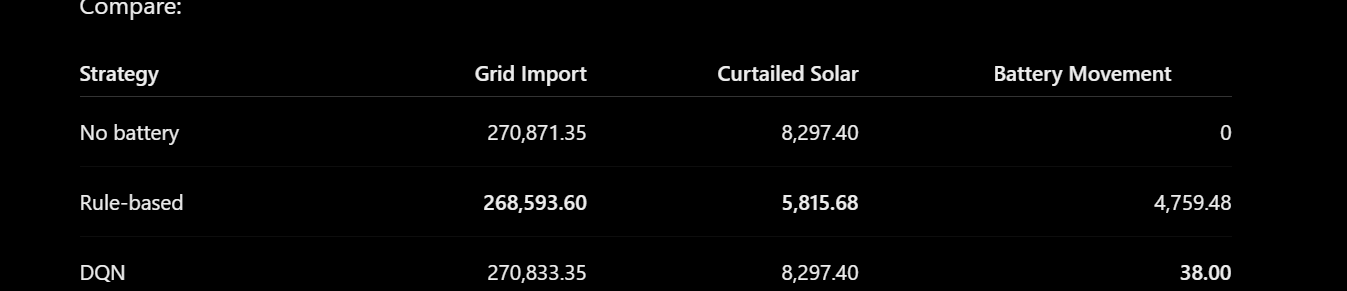

In [ ]:
# ============================================
# DQN ACTION EFFECTIVENESS DIAGNOSTIC
# ============================================

print("===== DQN ACTION EFFECTIVENESS =====")

print("\nTotal action requests:")
print("IDLE       :", dqn_metrics["IDLE_Actions"])
print("CHARGE     :", dqn_metrics["CHARGE_Actions"])
print("DISCHARGE  :", dqn_metrics["DISCHARGE_Actions"])

print("\nActual battery movement:")
print(
    "Charge:",
    dqn_results["Battery_Charge"].sum()
)

print(
    "Discharge:",
    dqn_results["Battery_Discharge"].sum()
)

print(
    "Total:",
    dqn_results["Battery_Charge"].sum()
    + dqn_results["Battery_Discharge"].sum()
)

print("\nTimesteps with actual battery movement:")

movement = (
    dqn_results["Battery_Charge"]
    + dqn_results["Battery_Discharge"]
)

print(
    (movement > 0).sum(),
    "out of",
    len(dqn_results)
)

print("\nAverage battery movement when movement occurred:")

print(
    movement[movement > 0].mean()
)

In [ ]:
# ============================================
# STEP 9 — CORRECTED DQN TRAINING
# ============================================

import random
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


# ============================================
# 1. Build 5-feature state
# ============================================

def get_state(data, step, soc):

    row = data.iloc[step]

    timestamp = pd.to_datetime(row["Timestamp"])

    hour = (
        timestamp.hour
        + timestamp.minute / 60.0
    )

    hour_angle = 2 * np.pi * hour / 24.0

    state = np.array([
        row["Predicted_Load_kWh"],
        row["Predicted_Solar_kWh"],
        soc,
        np.sin(hour_angle),
        np.cos(hour_angle)
    ], dtype=np.float32)

    return state


# ============================================
# 2. Normalize state
# ============================================

def normalize_state_v2(state):

    load = state[0] / 300.0
    solar = state[1] / 150.0
    soc = state[2] / 100.0

    # sin/cos already lie between -1 and 1
    hour_sin = state[3]
    hour_cos = state[4]

    return np.array([
        load,
        solar,
        soc,
        hour_sin,
        hour_cos
    ], dtype=np.float32)


# ============================================
# 3. DQN
# ============================================

class DQN_v2(nn.Module):

    def __init__(self, state_size=5, action_size=3):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(state_size, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, action_size)
        )

    def forward(self, state):

        return self.network(state)


# ============================================
# 4. Hyperparameters
# ============================================

STATE_SIZE = 5
ACTION_SIZE = 3

LEARNING_RATE = 0.0005

GAMMA = 0.95

BATCH_SIZE = 64
MEMORY_SIZE = 10000

EPISODES = 100

EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.97

TARGET_UPDATE = 10


# ============================================
# 5. Create networks
# ============================================

policy_net_v2 = DQN_v2(
    STATE_SIZE,
    ACTION_SIZE
)

target_net_v2 = DQN_v2(
    STATE_SIZE,
    ACTION_SIZE
)

target_net_v2.load_state_dict(
    policy_net_v2.state_dict()
)

target_net_v2.eval()


optimizer_v2 = optim.Adam(
    policy_net_v2.parameters(),
    lr=LEARNING_RATE
)

loss_function_v2 = nn.MSELoss()

memory_v2 = deque(
    maxlen=MEMORY_SIZE
)


# ============================================
# 6. Training
# ============================================

epsilon = EPSILON_START

episode_rewards_v2 = []


for episode in range(EPISODES):

    soc = 50.0

    total_reward = 0.0

    step = 0


    while step < len(rl_data) - 1:

        # ------------------------------------
        # Current state
        # ------------------------------------

        raw_state = get_state(
            rl_data,
            step,
            soc
        )

        state = normalize_state_v2(
            raw_state
        )


        # ------------------------------------
        # ε-greedy action
        # ------------------------------------

        if random.random() < epsilon:

            action = random.randrange(
                ACTION_SIZE
            )

        else:

            state_tensor = torch.tensor(
                state,
                dtype=torch.float32
            ).unsqueeze(0)

            with torch.no_grad():

                q_values = policy_net_v2(
                    state_tensor
                )

            action = torch.argmax(
                q_values,
                dim=1
            ).item()


        # ------------------------------------
        # Current data
        # ------------------------------------

        row = rl_data.iloc[step]

        load = row["Predicted_Load_kWh"]
        solar = row["Predicted_Solar_kWh"]


        # ------------------------------------
        # Energy simulator
        # ------------------------------------

        result = simulate_energy_flow(
            load=load,
            solar=solar,
            soc=soc,
            action=action
        )


        # ------------------------------------
        # Scale reward
        # ------------------------------------

        reward = result["reward"] / 100.0


        # ------------------------------------
        # Update SOC
        # ------------------------------------

        next_soc = result["new_soc"]


        # ------------------------------------
        # Next state
        # ------------------------------------

        next_step = step + 1

        raw_next_state = get_state(
            rl_data,
            next_step,
            next_soc
        )

        next_state = normalize_state_v2(
            raw_next_state
        )


        # ------------------------------------
        # Store experience
        # ------------------------------------

        memory_v2.append(
            (
                state,
                action,
                reward,
                next_state,
                False
            )
        )


        # ------------------------------------
        # Train
        # ------------------------------------

        if len(memory_v2) >= BATCH_SIZE:

            batch = random.sample(
                memory_v2,
                BATCH_SIZE
            )


            states = torch.tensor(
                np.array([
                    x[0] for x in batch
                ]),
                dtype=torch.float32
            )


            actions = torch.tensor(
                [
                    x[1] for x in batch
                ],
                dtype=torch.long
            ).unsqueeze(1)


            rewards = torch.tensor(
                [
                    x[2] for x in batch
                ],
                dtype=torch.float32
            )


            next_states = torch.tensor(
                np.array([
                    x[3] for x in batch
                ]),
                dtype=torch.float32
            )


            # Current Q
            current_q = policy_net_v2(
                states
            ).gather(
                1,
                actions
            ).squeeze(1)


            # Future Q
            with torch.no_grad():

                next_q = target_net_v2(
                    next_states
                ).max(1)[0]


            # Bellman target
            target_q = (
                rewards
                + GAMMA * next_q
            )


            # Loss
            loss = loss_function_v2(
                current_q,
                target_q
            )


            # Update network
            optimizer_v2.zero_grad()

            loss.backward()

            optimizer_v2.step()


        # Move forward
        soc = next_soc

        total_reward += result["reward"]

        step += 1


    # ----------------------------------------
    # Reduce exploration
    # ----------------------------------------

    epsilon = max(
        EPSILON_MIN,
        epsilon * EPSILON_DECAY
    )


    # ----------------------------------------
    # Update target network
    # ----------------------------------------

    if (episode + 1) % TARGET_UPDATE == 0:

        target_net_v2.load_state_dict(
            policy_net_v2.state_dict()
        )


    episode_rewards_v2.append(
        total_reward
    )


    if (episode + 1) % 10 == 0:

        print(
            f"Episode {episode + 1:3d} | "
            f"Reward: {total_reward:,.2f} | "
            f"Epsilon: {epsilon:.3f}"
        )


print("\n===== CORRECTED DQN TRAINING COMPLETE =====")

In [ ]:
# ============================================
# STEP 10 — EVALUATE CORRECTED DQN
# ============================================

def run_dqn_v2_episode(data, model):

    soc = 50.0

    total_grid_import = 0.0
    total_curtailed_solar = 0.0
    total_battery_movement = 0.0
    total_reward = 0.0

    action_counts = {
        0: 0,
        1: 0,
        2: 0
    }

    results = []

    for step in range(len(data)):

        row = data.iloc[step]

        load = row["Predicted_Load_kWh"]
        solar = row["Predicted_Solar_kWh"]

        # Build 5-feature state
        raw_state = get_state(
            data,
            step,
            soc
        )

        state = normalize_state_v2(raw_state)

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0)

        # Greedy action — NO exploration
        with torch.no_grad():

            q_values = policy_net_v2(
                state_tensor
            )

        action = torch.argmax(
            q_values,
            dim=1
        ).item()

        action_counts[action] += 1

        # Simulate energy flow
        result = simulate_energy_flow(
            load=load,
            solar=solar,
            soc=soc,
            action=action
        )

        # Update SOC
        soc = result["new_soc"]

        # Metrics
        total_grid_import += result["grid_import"]

        total_curtailed_solar += (
            result["curtailed_solar"]
        )

        total_battery_movement += (
            result["battery_charge"]
            + result["battery_discharge"]
        )

        total_reward += result["reward"]

        results.append({
            "Timestamp": row["Timestamp"],
            "Load": load,
            "Solar": solar,
            "Action": action,
            "Grid_Import": result["grid_import"],
            "Battery_Charge": result["battery_charge"],
            "Battery_Discharge": result["battery_discharge"],
            "Curtailed_Solar": result["curtailed_solar"],
            "SOC": soc,
            "Reward": result["reward"]
        })


    results_df = pd.DataFrame(results)

    metrics = {
        "Total_Grid_Import": total_grid_import,
        "Total_Curtailed_Solar": total_curtailed_solar,
        "Total_Battery_Movement": total_battery_movement,
        "Total_Reward": total_reward,
        "Final_SOC": soc,
        "IDLE_Actions": action_counts[0],
        "CHARGE_Actions": action_counts[1],
        "DISCHARGE_Actions": action_counts[2]
    }

    return results_df, metrics


# ============================================
# RUN EVALUATION
# ============================================

dqn_v2_results, dqn_v2_metrics = run_dqn_v2_episode(
    rl_data,
    policy_net_v2
)


print("===== CORRECTED DQN EVALUATION =====")

for key, value in dqn_v2_metrics.items():

    print(f"{key}: {value:.2f}")

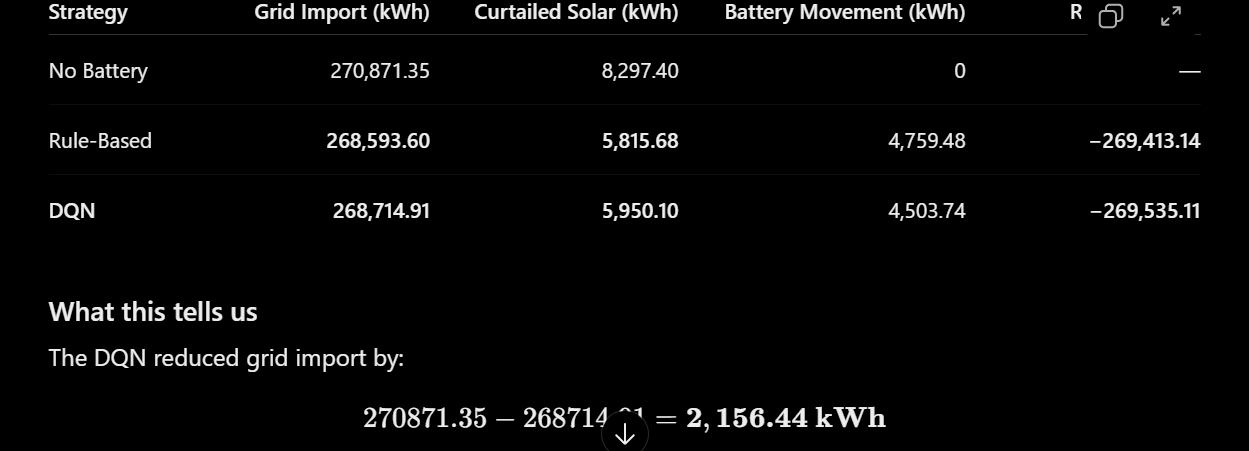

In [ ]:
# ============================================
# STEP 11 — FINAL RESULTS + COMPARISON GRAPHS
# ============================================

import pandas as pd
import matplotlib.pyplot as plt


# ============================================
# 1. Create final comparison table
# ============================================

comparison = pd.DataFrame({

    "Strategy": [
        "No Battery",
        "Rule-Based",
        "DQN"
    ],

    "Grid_Import_kWh": [
        no_battery_metrics["Total_Grid_Import"],
        rule_metrics["Total_Grid_Import"],
        dqn_v2_metrics["Total_Grid_Import"]
    ],

    "Solar_Curtailed_kWh": [
        no_battery_metrics["Total_Solar_Surplus"],
        rule_metrics["Total_Curtailed_Solar"],
        dqn_v2_metrics["Total_Curtailed_Solar"]
    ],

    "Battery_Movement_kWh": [
        0,
        rule_metrics["Total_Battery_Movement"],
        dqn_v2_metrics["Total_Battery_Movement"]
    ],

    "Total_Reward": [
        None,
        rule_metrics["Total_Reward"],
        dqn_v2_metrics["Total_Reward"]
    ]
})


print("===== FINAL COMPARISON =====")

display(
    comparison.round(2)
)


# ============================================
# 2. Calculate improvements vs No Battery
# ============================================

no_battery_grid = no_battery_metrics[
    "Total_Grid_Import"
]

dqn_grid = dqn_v2_metrics[
    "Total_Grid_Import"
]

rule_grid = rule_metrics[
    "Total_Grid_Import"
]


dqn_grid_reduction = (
    (no_battery_grid - dqn_grid)
    / no_battery_grid
) * 100


rule_grid_reduction = (
    (no_battery_grid - rule_grid)
    / no_battery_grid
) * 100


no_battery_curtailment = (
    no_battery_metrics["Total_Solar_Surplus"]
)

dqn_curtailment = (
    dqn_v2_metrics["Total_Curtailed_Solar"]
)

rule_curtailment = (
    rule_metrics["Total_Curtailed_Solar"]
)


dqn_curtailment_reduction = (
    (no_battery_curtailment - dqn_curtailment)
    / no_battery_curtailment
) * 100


rule_curtailment_reduction = (
    (no_battery_curtailment - rule_curtailment)
    / no_battery_curtailment
) * 100


print("\n===== REDUCTION VS NO BATTERY =====")

print(
    f"Rule-Based Grid Reduction: "
    f"{rule_grid_reduction:.2f}%"
)

print(
    f"DQN Grid Reduction: "
    f"{dqn_grid_reduction:.2f}%"
)

print(
    f"Rule-Based Curtailment Reduction: "
    f"{rule_curtailment_reduction:.2f}%"
)

print(
    f"DQN Curtailment Reduction: "
    f"{dqn_curtailment_reduction:.2f}%"
)


# ============================================
# 3. GRID IMPORT GRAPH
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Strategy"],
    comparison["Grid_Import_kWh"]
)

plt.title("Grid Energy Import Comparison")

plt.ylabel("Grid Import (kWh)")

plt.xlabel("Energy Management Strategy")

plt.tight_layout()

plt.show()


# ============================================
# 4. SOLAR CURTAILMENT GRAPH
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Strategy"],
    comparison["Solar_Curtailed_kWh"]
)

plt.title("Solar Curtailment Comparison")

plt.ylabel("Curtailed Solar (kWh)")

plt.xlabel("Energy Management Strategy")

plt.tight_layout()

plt.show()


# ============================================
# 5. BATTERY USAGE GRAPH
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Strategy"],
    comparison["Battery_Movement_kWh"]
)

plt.title("Battery Energy Movement")

plt.ylabel("Battery Movement (kWh)")

plt.xlabel("Energy Management Strategy")

plt.tight_layout()

plt.show()

The proposed DQN-based energy management agent achieved performance close to the rule-based baseline, reducing grid energy import by 0.80% and solar curtailment by 28.29% compared with the no-battery case

In [ ]:
# ==========================================
# FINAL DQN SIMULATION LOG
# ==========================================

dqn_results = []

env = SmartGridEnvironment(rl_data)
state = env.reset()

done = False

while not done:

    # Get current row
    row = rl_data.iloc[env.current_step]

    load = row["Predicted_Load_kWh"]
    solar = row["Predicted_Solar_kWh"]
    soc_before = env.soc

    # DQN chooses action
    state_tensor = torch.tensor(
        state,
        dtype=torch.float32
    ).unsqueeze(0)

    with torch.no_grad():
        q_values = policy_net_v2(state_tensor)

    action = q_values.argmax(dim=1).item()

    # Simulate energy flow
    next_state, reward, done, result = env.step(action)

    # Store everything
    dqn_results.append({
        "Timestamp": row["Timestamp"],
        "Predicted_Load_kWh": load,
        "Predicted_Solar_kWh": solar,
        "SOC_Before_kWh": soc_before,
        "Action": action,
        "Reward": reward,
        "Solar_to_Load_kWh": result["solar_to_load"],
        "Battery_Charge_kWh": result["battery_charge"],
        "Battery_Discharge_kWh": result["battery_discharge"],
        "Grid_Import_kWh": result["grid_import"],
        "Solar_Curtailed_kWh": result["curtailed_solar"],
        "SOC_After_kWh": result["new_soc"]
    })

dqn_results = pd.DataFrame(dqn_results)

# Convert action number to readable name
action_names = {
    0: "IDLE",
    1: "CHARGE",
    2: "DISCHARGE"
}

dqn_results["Action_Name"] = dqn_results["Action"].map(action_names)

print("DQN simulation completed.")
print("Shape:", dqn_results.shape)

display(dqn_results.head(10))

In [ ]:
# ==========================================
# SAVE FINAL DQN DASHBOARD DATA
# ==========================================

dqn_results.to_csv(
    "dqn_energy_management_results.csv",
    index=False
)

print("Saved successfully.")
print("Rows:", len(dqn_results))
print("Columns:", len(dqn_results.columns))

display(dqn_results.head())

In [ ]:
print("\nDQN ACTION DISTRIBUTION")
print(dqn_results["Action_Name"].value_counts())

print("\nFINAL SOC:")
print(dqn_results["SOC_After_kWh"].iloc[-1])

print("\nTOTAL GRID IMPORT:")
print(dqn_results["Grid_Import_kWh"].sum())

print("\nTOTAL SOLAR CURTAILMENT:")
print(dqn_results["Solar_Curtailed_kWh"].sum())

In [ ]:
# ==========================================
# DQN POLICY DIAGNOSTIC
# ==========================================

policy_net_v2.eval()

env = SmartGridEnvironment(rl_data)
state = env.reset()

for i in range(10):

    # Normalize exactly as during DQN evaluation
    state_for_model = state.copy()

    state_for_model[0] /= 300.0
    state_for_model[1] /= 150.0
    state_for_model[2] /= 100.0

    state_tensor = torch.tensor(
        state_for_model,
        dtype=torch.float32
    ).unsqueeze(0)

    with torch.no_grad():
        q_values = policy_net_v2(state_tensor).numpy()[0]

    action = int(np.argmax(q_values))

    print(
        f"Step {i} | "
        f"State={state} | "
        f"Q-values={q_values} | "
        f"Action={action}"
    )

    next_state, reward, done, result = env.step(action)

    state = next_state

    if done:
        break

In [ ]:
# ==========================================
# FINAL DQN EVALUATION + DASHBOARD LOG
# ==========================================

policy_net_v2.eval()

env = SmartGridEnvironment(rl_data)

state = env.reset()

dqn_results = []

done = False

while not done:

    # Current row
    row = rl_data.iloc[env.current_step]

    load = row["Predicted_Load_kWh"]
    solar = row["Predicted_Solar_kWh"]
    soc_before = env.soc

    # --------------------------------------
    # Normalize state exactly as DQN expects
    # --------------------------------------

    state_for_model = state.copy()

    state_for_model[0] /= 300.0
    state_for_model[1] /= 150.0
    state_for_model[2] /= 100.0

    state_tensor = torch.tensor(
        state_for_model,
        dtype=torch.float32
    ).unsqueeze(0)

    # --------------------------------------
    # DQN decision
    # --------------------------------------

    with torch.no_grad():
        q_values = policy_net_v2(state_tensor)

    action = q_values.argmax(dim=1).item()

    # --------------------------------------
    # Environment step
    # --------------------------------------

    next_state, reward, done, result = env.step(action)

    # --------------------------------------
    # Store results
    # --------------------------------------

    dqn_results.append({
        "Timestamp": row["Timestamp"],
        "Predicted_Load_kWh": load,
        "Predicted_Solar_kWh": solar,
        "SOC_Before_kWh": soc_before,

        "Action": action,

        "Action_Name": {
            0: "IDLE",
            1: "CHARGE",
            2: "DISCHARGE"
        }[action],

        "Reward": reward,

        "Solar_to_Load_kWh":
            result["solar_to_load"],

        "Battery_Charge_kWh":
            result["battery_charge"],

        "Battery_Discharge_kWh":
            result["battery_discharge"],

        "Grid_Import_kWh":
            result["grid_import"],

        "Solar_Curtailed_kWh":
            result["curtailed_solar"],

        "SOC_After_kWh":
            result["new_soc"]
    })

    state = next_state


dqn_results = pd.DataFrame(dqn_results)

print("======================================")
print("FINAL DQN EVALUATION")
print("======================================")

print("\nRows:", len(dqn_results))

print("\nACTION DISTRIBUTION:")
print(
    dqn_results["Action_Name"]
    .value_counts()
)

print("\nTOTAL GRID IMPORT:")
print(
    dqn_results["Grid_Import_kWh"].sum()
)

print("\nTOTAL SOLAR CURTAILMENT:")
print(
    dqn_results["Solar_Curtailed_kWh"].sum()
)

print("\nTOTAL BATTERY MOVEMENT:")
print(
    dqn_results["Battery_Charge_kWh"].sum()
    +
    dqn_results["Battery_Discharge_kWh"].sum()
)

print("\nFINAL SOC:")
print(
    dqn_results["SOC_After_kWh"].iloc[-1]
)

In [ ]:
# ==========================================
# PREPARE FINAL DASHBOARD DATA
# ==========================================

# Make sure timestamp is datetime
dqn_results["Timestamp"] = pd.to_datetime(
    dqn_results["Timestamp"]
)

# Save final DQN simulation
dqn_results.to_csv(
    "dqn_energy_management_results.csv",
    index=False
)

# Create summary metrics
dashboard_summary = {
    "Total Grid Import (kWh)": dqn_results["Grid_Import_kWh"].sum(),
    "Total Solar Curtailed (kWh)": dqn_results["Solar_Curtailed_kWh"].sum(),
    "Total Battery Charge (kWh)": dqn_results["Battery_Charge_kWh"].sum(),
    "Total Battery Discharge (kWh)": dqn_results["Battery_Discharge_kWh"].sum(),
    "Final Battery SOC (kWh)": dqn_results["SOC_After_kWh"].iloc[-1],
    "Average Load (kWh)": dqn_results["Predicted_Load_kWh"].mean(),
    "Average Solar (kWh)": dqn_results["Predicted_Solar_kWh"].mean()
}

print("===================================")
print("FINAL DASHBOARD DATA")
print("===================================")

for key, value in dashboard_summary.items():
    print(f"{key}: {value:.2f}")

print("\nAction distribution:")
print(dqn_results["Action_Name"].value_counts())

print("\nDashboard data ready.")

In [ ]:
# ==========================================
# SMART GRID AI DASHBOARD
# ==========================================

import plotly.graph_objects as go
from IPython.display import display, clear_output
import ipywidgets as widgets

# ------------------------------------------
# Dashboard title
# ------------------------------------------

print("=" * 70)
print("        AI SMART GRID ENERGY MANAGEMENT SYSTEM")
print("=" * 70)

# ------------------------------------------
# Timestamp selector
# ------------------------------------------

timestamps = dqn_results["Timestamp"].tolist()

timestamp_dropdown = widgets.SelectionSlider(
    options=timestamps,
    description="Time:",
    continuous_update=False,
    layout=widgets.Layout(width="95%")
)

# ------------------------------------------
# Output area
# ------------------------------------------

output = widgets.Output()


# ------------------------------------------
# Dashboard update function
# ------------------------------------------

def update_dashboard(change=None):

    with output:

        clear_output(wait=True)

        selected_time = timestamp_dropdown.value

        row = dqn_results[
            dqn_results["Timestamp"] == selected_time
        ].iloc[0]

        # Current values
        load = row["Predicted_Load_kWh"]
        solar = row["Predicted_Solar_kWh"]
        soc = row["SOC_After_kWh"]

        action = row["Action_Name"]

        grid = row["Grid_Import_kWh"]
        curtailed = row["Solar_Curtailed_kWh"]

        charge = row["Battery_Charge_kWh"]
        discharge = row["Battery_Discharge_kWh"]

        # ----------------------------------
        # Current status
        # ----------------------------------

        print(f"\nTimestamp: {selected_time}")

        print("\n" + "-" * 70)
        print("CURRENT GRID STATE")
        print("-" * 70)

        print(f"Predicted Load       : {load:.2f} kWh")
        print(f"Predicted Solar      : {solar:.2f} kWh")
        print(f"Battery SOC          : {soc:.2f} kWh")
        print(f"DQN Action           : {action}")
        print(f"Grid Import          : {grid:.2f} kWh")
        print(f"Battery Charge       : {charge:.2f} kWh")
        print(f"Battery Discharge    : {discharge:.2f} kWh")
        print(f"Solar Curtailment    : {curtailed:.2f} kWh")

        # ----------------------------------
        # Energy flow chart
        # ----------------------------------

        fig = go.Figure()

        fig.add_trace(
            go.Bar(
                x=["Load", "Solar", "Grid", "Battery"],
                y=[
                    load,
                    solar,
                    grid,
                    discharge - charge
                ],
                name="Energy"
            )
        )

        fig.update_layout(
            title="Current Energy Flow",
            yaxis_title="Energy (kWh)",
            height=400
        )

        fig.show()

        # ----------------------------------
        # Historical window
        # ----------------------------------

        current_index = dqn_results[
            dqn_results["Timestamp"] == selected_time
        ].index[0]

        start_index = max(0, current_index - 48)

        history = dqn_results.iloc[
            start_index:current_index + 1
        ]

        # Load vs Solar
        fig2 = go.Figure()

        fig2.add_trace(
            go.Scatter(
                x=history["Timestamp"],
                y=history["Predicted_Load_kWh"],
                mode="lines",
                name="Predicted Load"
            )
        )

        fig2.add_trace(
            go.Scatter(
                x=history["Timestamp"],
                y=history["Predicted_Solar_kWh"],
                mode="lines",
                name="Predicted Solar"
            )
        )

        fig2.update_layout(
            title="Load vs Solar Forecast",
            xaxis_title="Time",
            yaxis_title="Energy (kWh)",
            height=450
        )

        fig2.show()

        # ----------------------------------
        # Battery SOC
        # ----------------------------------

        fig3 = go.Figure()

        fig3.add_trace(
            go.Scatter(
                x=history["Timestamp"],
                y=history["SOC_After_kWh"],
                mode="lines",
                name="Battery SOC"
            )
        )

        fig3.update_layout(
            title="Battery State of Charge",
            xaxis_title="Time",
            yaxis_title="SOC (kWh)",
            height=400
        )

        fig3.show()


# ------------------------------------------
# Connect slider
# ------------------------------------------

timestamp_dropdown.observe(
    update_dashboard,
    names="value"
)

display(timestamp_dropdown)
display(output)

# Show first state
update_dashboard()

In [ ]:
# ==========================================
# STRATEGY PERFORMANCE COMPARISON
# ==========================================

import plotly.graph_objects as go

# ------------------------------------------
# Performance data
# ------------------------------------------

strategies = [
    "No Battery",
    "Rule-Based",
    "DQN"
]

grid_import = [
    270871.35,
    268593.60,
    268556.39
]

solar_curtailment = [
    8297.40,
    5815.68,
    5950.10
]

battery_movement = [
    0.00,
    4759.48,
    4503.74
]

# ------------------------------------------
# Print summary
# ------------------------------------------

print("=" * 70)
print("              STRATEGY COMPARISON")
print("=" * 70)

for i, strategy in enumerate(strategies):

    print(f"\n{strategy}")
    print(f"  Grid Import       : {grid_import[i]:,.2f} kWh")
    print(f"  Solar Curtailment : {solar_curtailment[i]:,.2f} kWh")
    print(f"  Battery Movement  : {battery_movement[i]:,.2f} kWh")


# ==========================================
# 1. GRID IMPORT
# ==========================================

fig1 = go.Figure()

fig1.add_trace(
    go.Bar(
        x=strategies,
        y=grid_import,
        text=[f"{x:,.0f}" for x in grid_import],
        textposition="auto"
    )
)

fig1.update_layout(
    title="Grid Energy Import Comparison",
    xaxis_title="Strategy",
    yaxis_title="Grid Import (kWh)",
    height=450
)

fig1.show()


# ==========================================
# 2. SOLAR CURTAILMENT
# ==========================================

fig2 = go.Figure()

fig2.add_trace(
    go.Bar(
        x=strategies,
        y=solar_curtailment,
        text=[f"{x:,.0f}" for x in solar_curtailment],
        textposition="auto"
    )
)

fig2.update_layout(
    title="Solar Curtailment Comparison",
    xaxis_title="Strategy",
    yaxis_title="Curtailed Solar (kWh)",
    height=450
)

fig2.show()


# ==========================================
# 3. BATTERY MOVEMENT
# ==========================================

fig3 = go.Figure()

fig3.add_trace(
    go.Bar(
        x=strategies,
        y=battery_movement,
        text=[f"{x:,.0f}" for x in battery_movement],
        textposition="auto"
    )
)

fig3.update_layout(
    title="Battery Energy Movement",
    xaxis_title="Strategy",
    yaxis_title="Battery Movement (kWh)",
    height=450
)

fig3.show()


# ==========================================
# REDUCTION CALCULATIONS
# ==========================================

no_battery_grid = grid_import[0]
no_battery_curtailment = solar_curtailment[0]

rule_grid_reduction = (
    (no_battery_grid - grid_import[1])
    / no_battery_grid
) * 100

dqn_grid_reduction = (
    (no_battery_grid - grid_import[2])
    / no_battery_grid
) * 100

rule_curtailment_reduction = (
    (no_battery_curtailment - solar_curtailment[1])
    / no_battery_curtailment
) * 100

dqn_curtailment_reduction = (
    (no_battery_curtailment - solar_curtailment[2])
    / no_battery_curtailment
) * 100


print("\n" + "=" * 70)
print("                 REDUCTION VS NO BATTERY")
print("=" * 70)

print(
    f"\nRule-Based Grid Reduction: "
    f"{rule_grid_reduction:.2f}%"
)

print(
    f"DQN Grid Reduction: "
    f"{dqn_grid_reduction:.2f}%"
)

print(
    f"\nRule-Based Curtailment Reduction: "
    f"{rule_curtailment_reduction:.2f}%"
)

print(
    f"DQN Curtailment Reduction: "
    f"{dqn_curtailment_reduction:.2f}%"
)

In [ ]:
# ==========================================
# FINAL SMART GRID PROTOTYPE DASHBOARD
# ==========================================

import plotly.graph_objects as go
from IPython.display import display, clear_output
import ipywidgets as widgets

# ------------------------------------------------
# FINAL METRICS
# ------------------------------------------------

NO_BATTERY_GRID = 270871.35
RULE_GRID = 268593.60
DQN_GRID = 268556.39

NO_BATTERY_CURTAIL = 8297.40
RULE_CURTAIL = 5815.68
DQN_CURTAIL = 5950.10

DQN_GRID_REDUCTION = (
    (NO_BATTERY_GRID - DQN_GRID)
    / NO_BATTERY_GRID
) * 100

DQN_CURTAIL_REDUCTION = (
    (NO_BATTERY_CURTAIL - DQN_CURTAIL)
    / NO_BATTERY_CURTAIL
) * 100


# ------------------------------------------------
# TITLE
# ------------------------------------------------

print("=" * 80)
print("          ⚡ AI SMART GRID ENERGY MANAGEMENT SYSTEM")
print("=" * 80)

print(
    "\nForecasting + Reinforcement Learning + "
    "Battery Energy Management"
)

print("\n" + "-" * 80)
print("                         KEY RESULTS")
print("-" * 80)

print(f"Grid Import Reduction      : {DQN_GRID_REDUCTION:.2f}%")
print(f"Solar Curtailment Reduction: {DQN_CURTAIL_REDUCTION:.2f}%")
print(f"Final Battery SOC          : {dqn_results['SOC_After_kWh'].iloc[-1]:.2f} kWh")
print(f"Average Load Forecast      : {dqn_results['Predicted_Load_kWh'].mean():.2f} kWh")
print(f"Average Solar Forecast     : {dqn_results['Predicted_Solar_kWh'].mean():.2f} kWh")


# ------------------------------------------------
# TIMESTAMP SELECTOR
# ------------------------------------------------

timestamps = dqn_results["Timestamp"].tolist()

timestamp_selector = widgets.SelectionSlider(
    options=timestamps,
    value=timestamps[0],
    description="Simulation Time:",
    continuous_update=False,
    layout=widgets.Layout(width="95%")
)

output = widgets.Output()


# ------------------------------------------------
# DASHBOARD FUNCTION
# ------------------------------------------------

def show_dashboard(change=None):

    with output:

        clear_output(wait=True)

        selected_time = timestamp_selector.value

        row = dqn_results[
            dqn_results["Timestamp"] == selected_time
        ].iloc[0]

        # Current values
        load = row["Predicted_Load_kWh"]
        solar = row["Predicted_Solar_kWh"]
        soc = row["SOC_After_kWh"]

        grid = row["Grid_Import_kWh"]
        charge = row["Battery_Charge_kWh"]
        discharge = row["Battery_Discharge_kWh"]
        curtailed = row["Solar_Curtailed_kWh"]

        action = row["Action_Name"]

        # --------------------------------------------
        # CURRENT STATE
        # --------------------------------------------

        print("\n" + "=" * 80)
        print(f"                    GRID STATE")
        print("=" * 80)

        print(f"\nTimestamp              : {selected_time}")

        print("\nENERGY FORECAST")
        print(f"  Load Forecast        : {load:.2f} kWh")
        print(f"  Solar Forecast       : {solar:.2f} kWh")

        print("\nBATTERY")
        print(f"  Battery SOC          : {soc:.2f} kWh")
        print(f"  Battery Charge       : {charge:.2f} kWh")
        print(f"  Battery Discharge    : {discharge:.2f} kWh")

        print("\nGRID")
        print(f"  Grid Import          : {grid:.2f} kWh")
        print(f"  Solar Curtailment    : {curtailed:.2f} kWh")

        print("\n" + "-" * 80)
        print(f"             DQN RECOMMENDED ACTION: {action}")
        print("-" * 80)

        # --------------------------------------------
        # HISTORICAL WINDOW
        # --------------------------------------------

        current_index = dqn_results[
            dqn_results["Timestamp"] == selected_time
        ].index[0]

        start_index = max(0, current_index - 48)

        history = dqn_results.iloc[
            start_index:current_index + 1
        ]

        # --------------------------------------------
        # LOAD VS SOLAR
        # --------------------------------------------

        fig1 = go.Figure()

        fig1.add_trace(
            go.Scatter(
                x=history["Timestamp"],
                y=history["Predicted_Load_kWh"],
                mode="lines",
                name="Load Forecast"
            )
        )

        fig1.add_trace(
            go.Scatter(
                x=history["Timestamp"],
                y=history["Predicted_Solar_kWh"],
                mode="lines",
                name="Solar Forecast"
            )
        )

        fig1.update_layout(
            title="Load vs Solar Forecast",
            xaxis_title="Time",
            yaxis_title="Energy (kWh)",
            height=420,
            hovermode="x unified"
        )

        fig1.show()

        # --------------------------------------------
        # BATTERY SOC
        # --------------------------------------------

        fig2 = go.Figure()

        fig2.add_trace(
            go.Scatter(
                x=history["Timestamp"],
                y=history["SOC_After_kWh"],
                mode="lines",
                name="Battery SOC"
            )
        )

        fig2.update_layout(
            title="Battery State of Charge",
            xaxis_title="Time",
            yaxis_title="SOC (kWh)",
            height=400,
            hovermode="x unified"
        )

        fig2.show()

        # --------------------------------------------
        # ENERGY FLOW
        # --------------------------------------------

        fig3 = go.Figure()

        fig3.add_trace(
            go.Bar(
                x=[
                    "Load",
                    "Solar",
                    "Grid Import",
                    "Battery Charge",
                    "Battery Discharge",
                    "Curtailed Solar"
                ],
                y=[
                    load,
                    solar,
                    grid,
                    charge,
                    discharge,
                    curtailed
                ]
            )
        )

        fig3.update_layout(
            title="Current Energy Flow",
            xaxis_title="Energy Component",
            yaxis_title="Energy (kWh)",
            height=420
        )

        fig3.show()


# ------------------------------------------------
# CONNECT SELECTOR
# ------------------------------------------------

timestamp_selector.observe(
    show_dashboard,
    names="value"
)

display(timestamp_selector)
display(output)

# Initial display
show_dashboard()